# FORGE — Walkthrough su dati reali AMZN 1D

Questo notebook percorre **l'intero pipeline FORGE** su 5 anni di candele giornaliere di Amazon (Jan 2021 → Jun 2026).

```
Candele OHLCV
  └─ build_features()      Feature engineering (EMA, RSI, BB, ATR, MACD, …)
       └─ forge()           Pipeline completa M0 → M1 → M2 → M3
            ├─ M0  MarketContext      — regime di mercato (bull/bear/…)
            ├─ M1  EventDiscovery     — segnali atomici consistenti
            ├─ M2  AlphaDiscovery     — contratti con direzione + holding period
            └─ M3  RuleDiscovery      — validazione IS + walk-forward OOS
```

**Output finale:** regole di trading statisticamente robuste (PARTIAL-EDGE / EDGE) già backtestabili.

## 1 — Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from forgedge import build_features, forge, forge_preset
from forgedge.rule_discovery import run_backtest

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 100})

DATA = Path("data/AMZN_1D.csv")

## 2 — Caricamento e pulizia dati

Il file CSV viene da Investing.com (formato standard: Date, Price, Open, High, Low, Vol., Change %).
Le colonne vengono rinominate e il volume viene convertito da formato `"31.50M"` a float.

In [2]:
raw = pd.read_csv(DATA)

# normalise column names: lower, no dots/spaces
raw.columns = [c.strip().lower().replace(".", "").replace(" ", "_") for c in raw.columns]

# rename to OHLCV convention
raw = raw.rename(columns={"price": "close", "vol": "volume", "change_%": "chg_pct"})

# parse date and sort ascending
raw["open_dt"] = pd.to_datetime(raw["date"], format="%m/%d/%Y")
raw = raw.sort_values("open_dt").reset_index(drop=True)

# numeric price columns
for col in ["open", "high", "low", "close"]:
    raw[col] = pd.to_numeric(
        raw[col].astype(str).str.replace(",", ""), errors="coerce"
    )

# volume: "31.50M" → 31_500_000 ; "1.2B" → 1_200_000_000
raw["volume"] = (
    raw["volume"]
    .astype(str)
    .str.replace("M", "e6")
    .str.replace("B", "e9")
)
raw["volume"] = pd.to_numeric(raw["volume"], errors="coerce").fillna(0)

# integer unix-ms timestamp required by build_features
raw["open_time"] = raw["open_dt"].astype("datetime64[ms]").astype("int64")

candles = raw[["open_time", "open_dt", "open", "high", "low", "close", "volume"]]

print(f"Barre: {len(candles)}")
print(f"Periodo: {candles['open_dt'].iloc[0].date()} → {candles['open_dt'].iloc[-1].date()}")
candles.tail(3)

Barre: 1378
Periodo: 2021-01-04 → 2026-06-30


,open_time,open_dt,open,high,low,close,volume
1375,1782432000000,2026-06-26,227.21,233.90,226.13,232.69,248370000.0
1376,1782691200000,2026-06-29,234.22,249.71,233.80,240.14,77620000.0
1377,1782777600000,2026-06-30,237.50,241.53,237.57,238.71,31500000.0


## 3 — Controllo qualità dati (`summary_report`)

`summary_report()` è un check diagnostico **opt-in**: non fa parte della pipeline di `forge()` e va chiamato esplicitamente sulla tabella che si intende passare avanti. Controlla, sulle sole colonne OHLC:

- **scale miste** (es. un feed che cambia unità di misura a metà serie),
- **incoerenze OHLC** (`high < low`, `close` fuori range, prezzi non positivi o NaN),
- **outlier** (rendimenti/range impossibili su una singola barra, con criterio MAD robusto),
- **barre mancanti/duplicate/fuori ordine** rispetto alla cadenza dedotta.

È puramente consultivo — non blocca mai la pipeline né solleva eccezioni — ma vale la pena eseguirlo *prima* di `build_features()`: un problema nei dati grezzi (es. un prezzo a zero, una barra duplicata) si propaga silenziosamente in ogni indicatore derivato.

In [3]:
from forgedge import summary_report

report = summary_report(candles, timestamp_col="open_dt", timeframe="1D", return_report=True)

print(f"\nEsito: {report.worst}  —  {'nessuna anomalia critica' if not report.has_critical else 'ANOMALIE CRITICHE da controllare'}")

════════════════════════════════════════════════════════════════════════
  FORGE — DATA QUALITY SUMMARY
════════════════════════════════════════════════════════════════════════
─ PANORAMICA ────────────────────────────────────────────────────────────
  barre              : 1378
  colonne prezzo     : ['open', 'high', 'low', 'close']
  intervallo date    : 2021-01-04 00:00:00  →  2026-06-30 00:00:00
  durata             : 2003 giorni
  cadenza inferita   : 1 days 00:00:00
  timeframe dichiar. : 1D
─ SCHEMA & VALORI MANCANTI ──────────────────────────────────────────────
  colonna      n_NaN   non_num      ≤0     inf
  open             0         -       0       0
  high             0         -       0       0
  low              0         -       0       0
  close            0         -       0       0
─ SCALA / MAGNITUDINE ───────────────────────────────────────────────────
  colonna            min       mediana           max     max/min
  open              82.8           169        276.

`summary_report` segnala qui un'anomalia reale: l'**ultima barra** del dataset (2026-06-30, la barra "di oggi" al momento dell'estrazione) ha `open` leggermente sotto il `low` registrato — sintomo tipico di una barra ancora **incompleta** (sessione di mercato in corso al momento dello scarico del CSV, quindi low/high non ancora definitivi). È un caso concreto in cui vale la pena controllare la sorgente dati piuttosto che fidarsi ciecamente: qui è innocuo (una sola barra recente, i pattern scoperti da `forge()` più avanti non dipendono da quella singola riga), ma con un feed live è il tipo di anomalia che va gestito esplicitamente (es. scartare la barra corrente non ancora chiusa) prima di alimentare la pipeline.

## 4 — Feature engineering

`build_features()` calcola indicatori tecnici sulle candele e restituisce la **KPI Table**: la struttura che serve a `forge()`. Ogni indicatore è descritto da un blocco di configurazione.

`atr` e `macd` sono indicatori di prima classe del KPI Builder (come `ema`/`rsi`/`bollinger_bands`) — disabilitati di default in `DEFAULT_CONFIG` perché richiedono parametri non standard (`atr` ha bisogno anche di `high`/`low`; `macd` legge `periods` come tripla `(fast, slow, signal)` invece di finestre indipendenti), ma pienamente utilizzabili passando una config esplicita come qui sotto.

Nota tecnica: `forge()` scarta automaticamente le feature che non sono "scale-free" (cioè la cui distribuzione dipende dal livello di prezzo) a meno che non possano essere combinate in un rapporto scale-free. Per oscillatori già limitati (RSI, %B) questo non è un problema; per indicatori illimitati come EMA, SMA e ATR serve configurare **almeno 2 periodi**, così FORGE costruisce automaticamente un rapporto fra il periodo veloce e quello lento (es. `ratio_close_atr14_atr28`) che è scale-free per costruzione. `macd` qui sotto è normalizzato dividendo per il prezzo, che migliora (ma non garantisce) la sua usabilità.

In [4]:
indicator_config = {
    "ema": {
        "enabled": True,
        "params": {"periods": [9, 50], "columns": ["close"]},
    },
    "rsi": {
        "enabled": True,
        "params": {"periods": [14, 25], "columns": ["close"]},
    },
    "bollinger_bands": {
        "enabled": True,
        "params": {"periods": [20], "columns": ["close"]},
    },
    "atr": {
        "enabled": True,
        # 2 periodi (non 1): FeatureGenerator accoppia atr14/atr28 in un
        # ratio scale-free — ATR (come EMA) non è limitato e non è
        # affidabile da solo. Richiede anche high/low.
        "params": {"periods": [14, 28], "columns": ["close"]},
    },
    "macd": {
        "enabled": True,
        # `periods` è una tripla piatta (fast, slow, signal), non finestre indipendenti
        "params": {"periods": [12, 26, 9], "columns": ["close"]},
    },
}

kpi = build_features(candles, indicator_config, timestamp_col="open_time")

feature_cols = [c for c in kpi.columns if c not in candles.columns]
print(f"KPI Table: {kpi.shape[0]} righe × {kpi.shape[1]} colonne")
print(f"Feature generate: {len(feature_cols)}")
print("Esempi:", ", ".join(feature_cols[:10]), "…")

KPI Table: 1378 righe × 23 colonne
Feature generate: 16
Esempi: color, close_ema_09, close_ema_50, close_rsi_14, close_rsi_25, close_bb_mid_20, close_bb_upper_20, close_bb_lower_20, close_bb_width_20, close_atr_14 …


## 5 — Configurazione preset

`forge_preset()` restituisce una tripletta di config pre-calibrate per il timeframe e l'asset.

| Preset | Filosofia | Copertura |
|--------|-----------|----------|
| **sniper** | solo segnali ad alta coerenza temporale | bassa |
| **balanced** | equilibrio qualità/copertura | media |
| **sweep** | esplora tutto, filtra poco | alta |
| **burst** | segnali ad alta frequenza di attivazione | media |

Per AMZN 1D usiamo **sweep** per massimizzare la copertura esplorativa.

In [5]:
event_cfg, alpha_cfg, rd_cfg = forge_preset(
    "sweep",
    timeframe="1D",
    asset="AMZN",
)

gp = event_cfg.gate_params
sc = rd_cfg.criteria
print(f"Gate: min_tpm={gp.min_tpm:.2f} ep/mese  max_dispersion={gp.max_dispersion}  mode='{gp.event_counting}'")
print(f"RD:   min_profit_factor={sc.min_profit_factor}  min_tpm={sc.min_tpm}")

Gate: min_tpm=0.30 ep/mese  max_dispersion=2.5  mode='episode'
RD:   min_profit_factor=2.0  min_tpm=0.3


## 6 — Esecuzione FORGE

Un'unica chiamata `forge()` esegue l'intero pipeline M0 → M3, più alcuni controlli di onestà statistica sempre attivi di default:

- **`TimeBudget`** — un unico asse temporale IS/OOS condiviso da Event Discovery e Alpha Discovery, con *purging* (rimuove le righe IS il cui ritorno forward "vede" oltre il confine OOS) per evitare che l'ultimo tratto IS sia in realtà scored su prezzi OOS.
- **`FastRotationNull`** (`fast_null=True` di default) — calcola il null di rotazione *esatto* della ricerca (ogni offset circolare della serie `close`, un solo pass FFT) e annota ogni contratto promosso con `rotation_p`: un contratto che vince solo la lotteria del multiple-testing della propria sessione di ricerca resta bloccato a `PARTIAL-EDGE` anche se le altre metriche sarebbero da `EDGE`.
- **`HypothesisLedger`** (`result.ledger`) — quante ipotesi la sessione ha davvero consumato (candidati × orizzonti × celle di griglia), per avere il denominatore del multiple-testing sempre sotto mano.

In [6]:
result = forge(
    kpi,
    ticker="AMZN",
    timeframe="1D",
    event_discovery_config=event_cfg,
    alpha_config=alpha_cfg,
    rule_discovery_config=rd_cfg,
    run_registry=False,
    progress=True,
)

print(f"\nM1 candidati  : {len(result.candidates)}")
print(f"M2 contratti  : {len(result.contracts)}")
print(f"M2 promossi   : {len(result.promoted)}")
print(f"M3 risposte   : {len(result.rule_responses)}")

print(f"\n{result.ledger.describe()}")
print(f"{result.time_budget.describe()}")
print(f"\n{result.calibration.summary()}")

[forge:AMZN +   0.0s] start — 1378 bars


[forge:AMZN +   0.0s] M0 Market Context — classifying regimes…


[forge:AMZN +   0.1s] M1 Event Discovery — mining event candidates…


[forge:AMZN +   5.1s] M1 Event Discovery — 3035 candidate(s)


[forge:AMZN +   5.1s] M2 Alpha Discovery — evaluating 3035 candidate(s)…


...

[forge:AMZN] M3 Rule Discovery |███████████████████████████·| 507/508 (100%)  32.5s

[forge:AMZN] M3 Rule Discovery |████████████████████████████| 508/508 (100%)  32.6s

[forge:AMZN +  50.9s] M3 Rule Discovery — 2 tradeable rule(s)


[forge:AMZN +  50.9s] done



M1 candidati  : 3035
M2 contratti  : 3035
M2 promossi   : 508
M3 risposte   : 508

hypothesis surface: 3035 candidates × 6(+enriched) horizons = 21940 return-tests; 508 promoted; ~75 grid cells/rule (total ≲ 1645500)
time budget: 1378 bars — IS [0, 965), purge 48 bar(s) before the split, embargo 0 bar(s), OOS [965, 1378)

Search-level rotation null  (K=964, alpha=0.05)

statistic       real  null mean   null q   emp p  verdict
abs_z         4.0938     4.0829   5.3619  0.3731  weak

Tippett (min-p, in-sample only): 0.3731  driven by 'abs_z'
Tippett empirical p             : 0.3731  (weak)
Survivors above null bar        : 0


## 7 — M1: Event Discovery

M1 genera **candidati atomici** (espressioni soglia `feature < valore`) filtrati dalla **ConsistencyGate** in base a frequenza mensile (`min_tpm`) e regolarità temporale (`max_dispersion` — indice di dispersione di Poisson). I candidati che superano il gate vengono composti in **AND** per formare segnali multivariati.

In [7]:
candidates = result.candidates
passed = [c for c in candidates if c.consistency_gate.passed]

print(f"Candidati totali : {len(candidates)}")
print(f"Gate superato    : {len(passed)}")
print(f"Atomici (1 feat) : {sum(1 for c in candidates if len(c.components) == 1)}")
print(f"AND composti     : {sum(1 for c in candidates if len(c.components) > 1)}")

Candidati totali : 3035
Gate superato    : 3035
Atomici (1 feat) : 1035
AND composti     : 2000


In [8]:
# Top 10 per episodi/mese
rows = []
for c in sorted(candidates, key=lambda x: x.activation_stats.mean_tpm, reverse=True)[:10]:
    s = c.activation_stats
    rows.append({
        "event_id":   c.event_id,
        "expression": c.expression,
        "tpm":        round(s.mean_tpm, 3),
        "dispersion": round(s.index_of_dispersion, 3),
        "n_ep":       s.n_activations,
        "gate":       "✓" if c.consistency_gate.passed else "✗",
    })

pd.DataFrame(rows)

,event_id,expression,tpm,dispersion,n_ep,gate
0,EVT-close_macd_12_26_sig-ZS-0266,zs_close_macd_12_26_signal_09_48 < -1,5.818,9.122,384,✓
1,EVT-ratio_close_ema09_em-ZS-0337,zs_ratio_close_ema09_ema50_48 < -1,5.439,8.520,359,✓
2,EVT-color-ZS-0025,zs_color_168 > 1,5.273,4.432,348,✓
3,EVT-close_macd_12_26-ZS-0239,zs_close_macd_12_26_48 < -1,5.273,8.097,348,✓
4,EVT-diffnorm_close_natr1-ZS-0735,zs_diffnorm_close_natr14_natr28_48 > 1,5.227,6.256,345,✓
5,EVT-diffnorm_close_ema09-ZS-0365,zs_diffnorm_close_ema09_ema50_48 > 1,5.212,8.699,344,✓
6,EVT-diffnorm_close_atr14-ZS-0626,zs_diffnorm_close_atr14_atr28_48 > 1,5.197,6.224,343,✓
7,EVT-diffnorm_close_ema09-ZS-0364,zs_diffnorm_close_ema09_ema50_48 < -1,5.136,8.410,339,✓
8,EVT-ratio_close_ema09_em-ZS-0338,zs_ratio_close_ema09_ema50_48 > 1,4.985,8.342,329,✓
9,EVT-ratio_close_natr14_n-ZS-0679,zs_ratio_close_natr14_natr28_48 > 1,4.985,6.503,329,✓


## 8 — M2: Alpha Discovery

Per ogni candidato M1 promosso, M2 ricerca il **contratto ottimale**:
- **direzione** (long / short)
- **holding period h\*** (da 1 a `max_holding_period` barre)
- **sell_pct**: percentuale di gain target

Vengono promossi solo i contratti con `lift` statisticamente significativo.

In [9]:
promoted = result.promoted

print(f"Contratti totali M2 : {len(result.contracts)}")
print(f"Promossi            : {len(promoted)}")
print(f"  long              : {sum(1 for c in promoted if c.direction == 'long')}")
print(f"  short             : {sum(1 for c in promoted if c.direction == 'short')}")

Contratti totali M2 : 3035
Promossi            : 508
  long              : 184
  short             : 324


In [10]:
# Top 10 contratti promossi per lift
rows = []
for c in sorted(promoted, key=lambda x: x.event_stats.lift, reverse=True)[:10]:
    dt = c.derived_target
    rows.append({
        "expression":  c.event_expression,
        "direction":   c.direction,
        "h*":          dt.holding_period_h,
        "sell_pct %":  round(dt.sell_pct * 100, 2),
        "lift":        round(c.event_stats.lift, 4),
        "activations": c.event_stats.n_activations,
    })

pd.DataFrame(rows)

,expression,direction,h*,sell_pct %,lift,activations
0,zs_color_48 < -1 AND pr_close_rsi_14_168 < 0.1...,long,3,3.58,0.6565,11
1,zs_color_48 < -1 AND zs_close_rsi_14_168 < -1,long,3,3.72,0.5912,12
2,close_rsi_14 < 39.2903 AND delta_ratio_close_r...,long,12,9.79,0.5545,17
3,close_rsi_14 < 36.3905 AND delta_bb_pct_b_clos...,long,2,2.18,0.5390,18
4,close_rsi_25 < 40.3848,long,10,7.94,0.5268,96
5,close_rsi_14 < 36.3905 AND delta_spread_close_...,long,1,1.25,0.5250,22
6,close_rsi_25 < 39.2649,long,10,9.34,0.5205,76
7,delta_close_rsi_14_12 < -24.9697,long,2,1.99,0.5191,24
8,pr_color_168 < 0.247024 AND bb_pct_b_close_20 ...,long,2,2.11,0.5129,16
9,zs_color_168 < -1 AND bb_pct_b_close_20 < 0.16...,long,2,1.99,0.5093,17


## 9 — M3: Rule Discovery

M3 valida ogni contratto promosso con:
1. **Backtest IS** — profit factor, win rate, expectancy
2. **Walk-forward OOS** — 4 split espandenti; consistency e degradazione
3. **Validazione statistica** — Deflated Sharpe, t-test win rate
4. **Rotation null di ricerca** (`rotation_p`) — un contratto con `rotation_p > 0.05` non può raggiungere `EDGE` a prescindere dalle altre metriche: resta bloccato a `PARTIAL-EDGE`, perché il suo vantaggio non si distingue da quello del miglior candidato su una rotazione casuale della stessa serie.

Verdetti:
- `EDGE` — robusto IS + OOS + rotation null superata
- `PARTIAL-EDGE` — IS forte, OOS sufficiente ma non pieno, oppure rotation null non superata
- `NON-EDGE` — non supera i criteri

In [11]:
verdicts = Counter(r.verdict for _, r in result.rule_responses)
print("Verdetti M3:")
for v, n in sorted(verdicts.items(), key=lambda x: -x[1]):
    bar = "█" * n
    print(f"  {v:<16} {n:>4}  {bar}")

Verdetti M3:
  NON-EDGE          506  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  PARTIAL-EDGE        2  ██


## 10 — Tabella PARTIAL-EDGE

Tutti i segnali con verdetto `PARTIAL-EDGE`, ordinati per profit factor IS — con `rotation_p` a fianco: se è alto (vicino a 1), il segnale è statisticamente indistinguibile da quello che si otterrebbe cercando sulla stessa serie ruotata casualmente.

In [12]:
partial_edge = [
    (cc, r)
    for cc, r in result.rule_responses
    if r.verdict == "PARTIAL-EDGE"
]
partial_edge.sort(key=lambda x: x[1].in_sample_summary.profit_factor, reverse=True)

rows = []
for cc, r in partial_edge:
    iss = r.in_sample_summary
    wf  = r.walk_forward
    oos = wf.oos_summary if wf else None
    dt  = cc.derived_target
    rows.append({
        "expression":  cc.event_expression,
        "dir":         cc.direction,
        "h*":          dt.holding_period_h if dt else None,
        "IS PF":       round(iss.profit_factor, 2),
        "IS WR %":     round(iss.win_rate_pct * 100, 1),
        "IS trades":   iss.total_trades,
        "OOS PF":      round(oos.profit_factor, 2) if oos and oos.total_trades else None,
        "OOS trades":  oos.total_trades if oos else None,
        "consistency": f"{wf.n_profitable_splits}/{len(wf.splits)}" if wf else None,
        "rotation_p":  round(cc.rotation_p, 3) if cc.rotation_p is not None else None,
    })

df_pe = pd.DataFrame(rows)
print(f"{len(df_pe)} segnali PARTIAL-EDGE su {len(result.promoted)} contratti promossi")
df_pe

2 segnali PARTIAL-EDGE su 508 contratti promossi


,expression,dir,h*,IS PF,IS WR %,IS trades,OOS PF,OOS trades,consistency,rotation_p
0,close_rsi_25 > 61.0731,short,1,1.85,65.1,106,1.14,132,1/4,1.0
1,close_rsi_25 < 42.4654,long,7,1.76,66.1,118,1.21,145,3/4,1.0


## 11 — Dettaglio completo sui segnali

Con solo 2 `PARTIAL-EDGE` sopravvissuti (vedi sezione 14 per il perché), li mostriamo entrambi per intero: métriche IS/OOS, split walk-forward, e — soprattutto — `rejection_reasons`, la lista esplicita dei motivi per cui ciascuno non ha raggiunto `EDGE`. Il pipeline non nasconde la debolezza di un segnale: la dichiara.

La checklist di pre-produzione di FORGE (`docs/specs/how_to_use_en.md`, §12) usa `walk_forward.consistency >= 0.50` come soglia minima ragionevole (almeno metà degli split OOS profittevoli) — la applichiamo qui per marcare quale dei due è il meno fragile.

In [13]:
def print_signal_detail(cc, r, rank):
    iss = r.in_sample_summary
    wf  = r.walk_forward
    oos = wf.oos_summary if wf else None
    dt  = cc.derived_target
    sv  = r.statistical_validation
    wfv = wf.oos_validation if wf else None

    print(f"{'═'*72}")
    print(f"  #{rank}  {r.verdict}")
    print(f"  Regola:  {cc.event_expression}")
    if dt:
        print(f"  Setup:   {cc.direction.upper()}  h*={dt.holding_period_h} barre  target={dt.sell_pct*100:.2f}%")
    print()
    print(f"  ┌─ IN-SAMPLE ({iss.total_trades} trades) ")
    print(f"  │  PF={iss.profit_factor:.3f}  WR={iss.win_rate_pct*100:.1f}%  Expect={iss.expectancy*100:.2f}%  TPM={iss.tpm_mu:.2f}")
    if sv:
        print(f"  │  DSharpe={sv.deflated_sharpe:.2f}  WR t={sv.ttest_winrate_t:.2f}  "
              f"trials={sv.n_trials_tested}  stability={sv.temporal_stability}")

    if oos and oos.total_trades:
        consistency = f"{wf.n_profitable_splits}/{len(wf.splits)}"
        print(f"  ├─ OOS AGGREGATO ({oos.total_trades} trades, {consistency} split profittevoli)")
        print(f"  │  PF={oos.profit_factor:.3f}  WR={oos.win_rate_pct*100:.1f}%  Expect={oos.expectancy*100:.2f}%  TPM={oos.tpm_mu:.2f}")
        if wfv:
            print(f"  │  stability={wfv.temporal_stability}  PF½1={wfv.pf_first_half:.2f}  PF½2={wfv.pf_second_half:.2f}")

    if wf and wf.splits:
        print(f"  ├─ WALK-FORWARD SPLITS")
        for sp in wf.splits:
            ts = sp.test_summary
            ok = "✓" if ts.profit_factor > 1 else "✗"
            pf_str = f"{ts.profit_factor:.2f}" if ts.profit_factor < 9999 else "∞"
            print(f"  │  [{ok}] {sp.test_from[:10]}→{sp.test_to[:10]}  "
                  f"PF={pf_str:<6}  WR={ts.win_rate_pct*100:.0f}%  t={ts.total_trades}")

    print(f"  ├─ ROTATION NULL (ricerca)")
    print(f"  │  rotation_p={cc.rotation_p:.4f}  soglia={cc.rotation_threshold:.4f}  "
          f"{'>> supera il null bar' if cc.rotation_p is not None and cc.rotation_p <= 0.05 else '>> NON distinguibile da una rotazione casuale'}")

    if r.rejection_reasons:
        print(f"  ├─ PERCHÉ NON È EDGE")
        for reason in r.rejection_reasons:
            print(f"  │  · {reason}")

    print(f"  └{'─'*69}")
    print()

In [14]:
for i, (cc, r) in enumerate(partial_edge, 1):
    print_signal_detail(cc, r, i)

meets_checklist = [
    (cc, r) for cc, r in partial_edge
    if r.walk_forward and r.walk_forward.consistency >= 0.50
]
print(f"Segnali con walk_forward.consistency >= 50% (soglia della checklist di pre-produzione): "
      f"{len(meets_checklist)}/{len(partial_edge)}")

════════════════════════════════════════════════════════════════════════
  #1  PARTIAL-EDGE
  Regola:  close_rsi_25 > 61.0731
  Setup:   SHORT  h*=1 barre  target=1.11%

  ┌─ IN-SAMPLE (106 trades) 
  │  PF=1.849  WR=65.1%  Expect=0.50%  TPM=2.08
  │  DSharpe=2.66  WR t=8.40  trials=40  stability=PASS
  ├─ OOS AGGREGATO (132 trades, 1/4 split profittevoli)
  │  PF=1.141  WR=58.3%  Expect=0.10%  TPM=2.20
  │  stability=WARN  PF½1=0.82  PF½2=1.49
  ├─ WALK-FORWARD SPLITS
  │  [✗] 2021-07-01→2022-10-01  PF=0.71    WR=81%  t=16
  │  [✗] 2022-10-01→2024-01-01  PF=0.80    WR=46%  t=35
  │  [✓] 2024-01-01→2025-04-01  PF=1.81    WR=67%  t=52
  │  [✗] 2025-04-01→2026-07-01  PF=0.81    WR=45%  t=29
  ├─ ROTATION NULL (ricerca)
  │  rotation_p=1.0000  soglia=5.3619  >> NON distinguibile da una rotazione casuale
  ├─ PERCHÉ NON È EDGE
  │  · PF 1.85 < 2.0
  │  · active_months 20/51 = 39% < 80%
  │  · OOS consistency 0.25 < 0.5
  │  · search-level rotation null not cleared (rotation_p=1.0000 > 0.05

## 12 — Dove si attivano i segnali

Un grafico vale più di una tabella di metriche: per ciascun segnale `PARTIAL-EDGE` (fino a un massimo di 5, per profit factor IS) sovrapponiamo i punti di attivazione della regola al prezzo di chiusura di AMZN. Permette di vedere a colpo d'occhio **quando** il segnale scatta — e se i punti si concentrano in fasi di mercato particolari o sono distribuiti nel tempo.

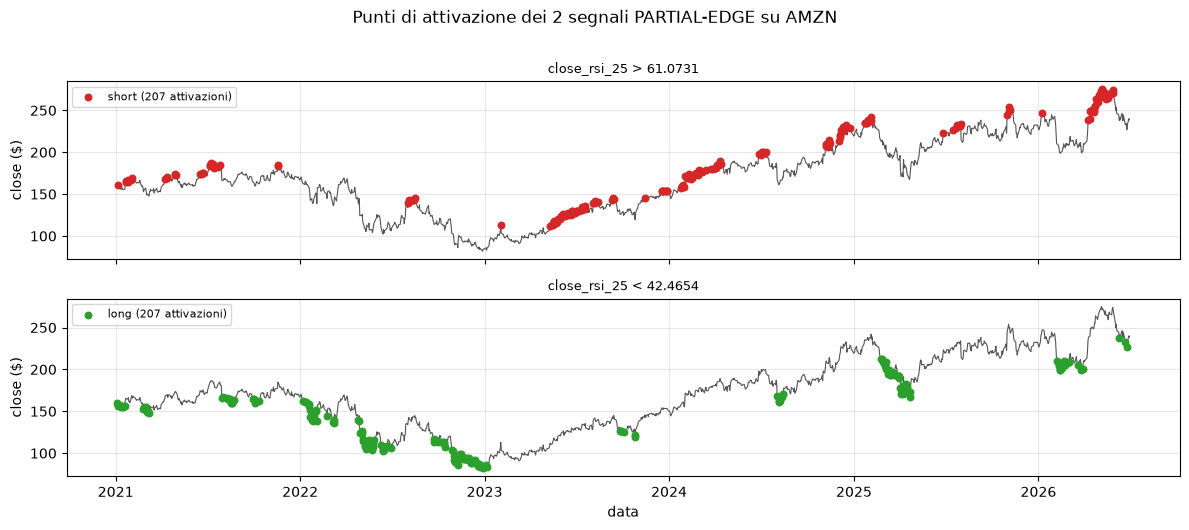

In [15]:
cand_by_id = {c.event_id: c for c in result.candidates}
price = result.enriched.set_index("open_dt")["close"]
top5 = partial_edge[:5]

fig, axes = plt.subplots(len(top5), 1, figsize=(12, 2.6 * len(top5)), sharex=True)
for ax, (cc, r) in zip(axes, top5):
    cand = cand_by_id.get(cc.event_candidate_id)
    ax.plot(price.index, price.values, color="#555", lw=0.8)
    if cand is not None and cand.event_series is not None:
        ev = cand.event_series.reindex(price.index).fillna(0).astype(bool)
        color = "#d62728" if cc.direction == "short" else "#2ca02c"
        ax.scatter(price.index[ev], price.values[ev], color=color, s=22, zorder=5,
                   label=f"{cc.direction} ({int(ev.sum())} attivazioni)")
        ax.legend(loc="upper left", fontsize=8)
    ax.set_title(cc.event_expression, fontsize=9)
    ax.set_ylabel("close ($)")

axes[-1].set_xlabel("data")
fig.suptitle(f"Punti di attivazione dei {len(top5)} segnali PARTIAL-EDGE su AMZN", y=1.01)
plt.tight_layout()
plt.show()

## 13 — Confronto con Buy & Hold

Le metriche IS/OOS dicono se una regola è statisticamente robusta, ma non dicono *quanto* renderebbe rispetto alla strategia più semplice possibile: comprare e tenere. Ricostruiamo l'equity curve di ciascun segnale `PARTIAL-EDGE` con `run_backtest()` usando i parametri validati da M3 (`r.validated_rule.params`), e la confrontiamo con il Buy & Hold di AMZN sullo stesso periodo.

Equity come **somma aritmetica** dei rendimenti netti per trade, non capitale composto: il backtest apre posizioni sovrapposte senza position sizing, quindi comporre sarebbe fittizio — comprimere trade concorrenti in una singola serie di capitale li tratterebbe come sequenziali quando non lo sono. Stessa convenzione di `rule_performance_report()` (sezione 15.3).

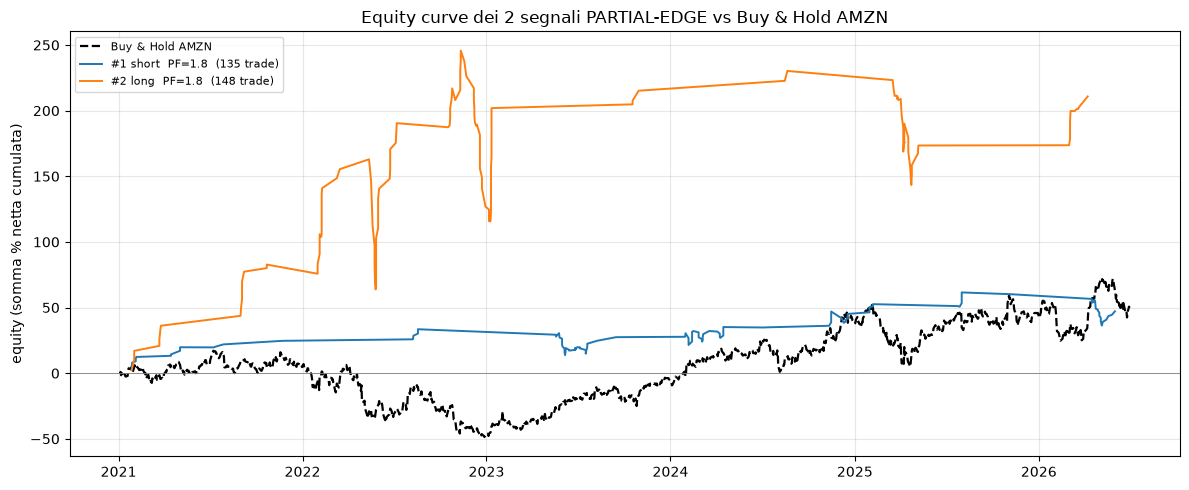

,expression,direction,trades,total return (pt %),max drawdown (pt %)
#,,,,,
1,close_rsi_25 > 61.0731,short,135,47.1,-25.2
2,close_rsi_25 < 42.4654,long,148,210.8,-130.0
B&H,Buy & Hold AMZN,long,1,49.8,-65.7


In [16]:
# % return, confrontabile in modo additivo col Buy & Hold
bh_equity = (price / price.iloc[0] - 1) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(bh_equity.index, bh_equity.values, color="black", lw=1.6, ls="--", label="Buy & Hold AMZN")

summary_rows = []
for i, (cc, r) in enumerate(top5, 1):
    cand = cand_by_id.get(cc.event_candidate_id)
    if cand is None or r.validated_rule is None:
        continue
    frame = result.enriched.copy()
    frame["__chart_signal__"] = cand.event_series.reindex(frame["open_dt"]).fillna(0).values
    _, trades = run_backtest(frame, "__chart_signal__", r.validated_rule.params,
                             timestamp_col="open_dt", return_trades=True)
    if len(trades) == 0:
        continue
    trades = trades.sort_values("exit_dt")
    # Somma aritmetica, non capitale composto (vedi nota sopra).
    eq = trades["net_pct_gain"].cumsum() * 100
    eq.index = pd.to_datetime(trades["exit_dt"])
    pf = r.in_sample_summary.profit_factor
    pf_label = "∞" if pf >= 999 else f"{pf:.1f}"
    ax.plot(eq.index, eq.values, lw=1.4,
            label=f"#{i} {cc.direction}  PF={pf_label}  ({len(trades)} trade)")
    dd = (eq - eq.cummax()).min()
    summary_rows.append({
        "#": i,
        "expression": cc.event_expression,
        "direction": cc.direction,
        "trades": len(trades),
        "total return (pt %)": round(eq.iloc[-1], 1),
        "max drawdown (pt %)": round(dd, 1),
    })

ax.axhline(0, color="gray", lw=0.6)
ax.set_ylabel("equity (somma % netta cumulata)")
ax.set_title(f"Equity curve dei {len(top5)} segnali PARTIAL-EDGE vs Buy & Hold AMZN")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

bh_total_return = bh_equity.iloc[-1]
bh_dd = (bh_equity - bh_equity.cummax()).min()
summary_rows.append({"#": "B&H", "expression": "Buy & Hold AMZN", "direction": "long",
                     "trades": 1, "total return (pt %)": round(bh_total_return, 1),
                     "max drawdown (pt %)": round(bh_dd, 1)})
pd.DataFrame(summary_rows).set_index("#")

## 14 — Interpretazione

### Il risultato onesto: quasi nessun edge, ed è la cosa giusta

Su 3035 candidati M1 e 508 contratti M2 promossi, solo **2** raggiungono `PARTIAL-EDGE` — e nessuno raggiunge `EDGE`. `result.calibration.tippett_p` (sezione 6) è ≈0.37: il miglior segnale trovato non è statisticamente distinguibile da quello che si otterrebbe cercando sulla stessa serie ruotata casualmente in circa 1 caso su 3. Entrambi i sopravvissuti hanno `rotation_p=1.0` — il caso peggiore possibile: **ogni singola** rotazione della serie produce un candidato altrettanto buono o migliore.

Questo è esattamente il comportamento atteso su un titolo come AMZN — large cap, altamente liquido, ampiamente arbitraggiato — e non un difetto del pipeline. È il `FastRotationNull` di default (sezione 6) a impedire di scambiare rumore per segnale: prima che questo controllo fosse parte del pipeline, una ricerca `sweep` su 3035 candidati avrebbe prodotto decine di falsi positivi con profit factor apparentemente alti solo per effetto del multiple-testing. Su un asset meno efficiente e più volatile (es. una crypto di seconda fascia) `tippett_p` tende a scendere sotto 0.05 e più segnali superano il null bar — la differenza sta nell'asset, non nel metodo.

### I due sopravvissuti: RSI mean-reversion, deboli ma non casuali

- **`close_rsi_25 < 42.4654` (long, h\*=7)** — consistency 75% (3/4 split OOS), DSharpe=1.01 (debole), `active_months` 39% (sotto la soglia 80% richiesta per EDGE). Il più solido dei due secondo la checklist di pre-produzione (`walk_forward.consistency >= 0.50`).
- **`close_rsi_25 > 61.0731` (short, h\*=1)** — consistency solo 25% (1/4 split OOS): profittevole in un solo trimestre su quattro, il classico segnale di un edge che non generalizza.

Entrambi sono varianti dello stesso ingrediente — RSI a 25 periodi in zona ipercomprata/ipervenduta — non due scoperte indipendenti. Nessuno dei due avrebbe superato una richiesta di `EDGE` pieno (serve `PF >= 2.0`, `active_months >= 80%` **e** `rotation_p <= 0.05` insieme).

### Come leggere questo notebook

- Il grafico delle attivazioni (sezione 12) e il confronto Buy & Hold (sezione 13) mostrano la meccanica — dove scatta la regola, quanto renderebbe — indipendentemente da quanto il segnale sia solido: sono strumenti diagnostici, non un sigillo di approvazione.
- `rejection_reasons` (sezione 11) è la lista esplicita, per ciascun segnale, del perché non è `EDGE` — leggerla è più informativo di guardare solo il verdetto.
- **Non promuovere né #1 né #2 in produzione così come sono.** Sono l'esempio di cosa succede quando il pipeline *non* trova un edge convincente, e di come lo comunica — non un invito al paper trading.

## 15 — Produzione: generare segnali su dati nuovi

Tutto quello che precede è **ricerca**: una sessione una tantum che scopre e valida regole su una finestra storica fissa. Mettere una regola "in produzione" non significa rieseguire `forge()` — significa **riusare** l'oggetto scoperto (`EventCandidate` + parametri validati) su barre che arrivano dopo, senza ricalibrare nulla. Tre strumenti, tre scopi diversi:

1. **`EventCandidate.apply(nuove_barre)`** — replay deterministico del segnale grezzo: "la condizione è attiva adesso?" Nessun accesso alla sessione originale, nessuna ri-ottimizzazione.
2. **`RuleDiscovery` rieseguito sui dati estesi** — un verdetto *fresco* (`EDGE`/`PARTIAL-EDGE`/`NON-EDGE`): l'edge tiene ancora sulle barre nuove?
3. **`rule_performance_report()`** — la dashboard HTML di monitoraggio continuo: equity vs Buy & Hold, andamento mensile delle attivazioni, decadimento dell'expectancy, badge "segnale attivo ora".

**Nota sui dati di questo esempio:** non avendo barre AMZN genuinamente più recenti di quelle già usate nella sessione, qui la "coda" del dataset stesso rappresenta le "barre nuove" — un mero stand-in dimostrativo. In un uso reale, `nuove_barre` sarebbero candele arrivate dopo la sessione di scoperta, passate attraverso lo stesso `build_features()` di sezione 4.

In [17]:
# Selezioniamo il segnale con la walk-forward consistency migliore (sezione 11)
signal_cc, signal_r = max(
    partial_edge, key=lambda x: x[1].walk_forward.consistency if x[1].walk_forward else 0
)
cand_by_id = {c.event_id: c for c in result.candidates}
signal_cand = cand_by_id[signal_cc.event_candidate_id]  # l'EventCandidate: qui vive .apply()

print(f"Regola scelta: {signal_cc.event_expression}")
print(f"Direzione: {signal_cc.direction}  h*={signal_cc.derived_target.holding_period_h}  "
      f"sell_pct={signal_cc.derived_target.sell_pct:.4f}")
print(f"Verdetto originale: {signal_r.verdict}  consistency={signal_r.walk_forward.consistency:.0%}")

Regola scelta: close_rsi_25 < 42.4654
Direzione: long  h*=7  sell_pct=0.0593
Verdetto originale: PARTIAL-EDGE  consistency=75%


### 15.1 — Il segnale grezzo: `EventCandidate.apply()`

`apply()` usa l'espressione e le soglie fissate al momento della scoperta — richiede solo le colonne che l'espressione referenzia. Usiamo `event_frame` (non `enriched`) perché le espressioni possono referenziare feature derivate come `ratio_`/`delta_`/`zs_`, presenti solo nel frame post-Event-Discovery, non nella KPI Table grezza.

In [18]:
# Stand-in per "barre nuove": la coda di event_frame (vedi nota sopra)
# event_frame ha un DatetimeIndex chiamato open_dt (non una colonna) — usiamo l'indice.
new_bars = result.event_frame.tail(300)

# apply() restituisce 0.0/1.0/NaN (non bool): normalizziamo esplicitamente
active = signal_cand.apply(new_bars).fillna(0).astype(bool)
n_fires = int(active.sum())
print(f"Attivazioni sulle ultime {len(new_bars)} barre: {n_fires}")
if active.iloc[-1]:
    print(f"⚠ Segnale ATTIVO sull'ultima barra disponibile ({new_bars.index[-1].date()})")
else:
    fire_dates = new_bars.index[active.to_numpy()]
    if len(fire_dates):
        print(f"Ultima attivazione: {fire_dates[-1].date()}")
    else:
        print("Nessuna attivazione in questa finestra")

Attivazioni sulle ultime 300 barre: 23
Ultima attivazione: 2026-06-25


### 15.2 — Verifica se l'edge tiene ancora: `RuleDiscovery`, non `AlphaDiscovery`

Per verificare se un edge scoperto regge su dati nuovi, lo strumento corretto è **Rule Discovery**, non Alpha Discovery. `AlphaDiscovery` *ri-deriva* direzione e orizzonte ottimale da qualunque dato gli si passi: su uno storico che include regimi di mercato incompatibili (es. un evento long scoperto nel 2024-2026 che era attivo anche durante un crollo nel 2022, dove la stessa condizione precedeva ritorni fortemente negativi), il vantaggio medio delle due popolazioni opposte tende a cancellarsi verso zero — e `AlphaDiscovery` restituisce `direction="undetermined"` ("no derivable target"). Non perché l'edge sia sparito, ma perché la domanda posta è quella sbagliata.

`RuleDiscovery` non ri-deriva nulla: prende l'`AlphaContract` con `direction`, `holding_period_h` e `sell_pct` **già fissati**, e misura se la regola produce ancora valore atteso positivo sulle barre nuove.

In [19]:
from forgedge import RuleDiscovery

# In produzione: eval_df = dati della sessione di scoperta + barre genuinamente nuove.
# Qui, non avendo dati più recenti, rieseguiamo sull'intero event_frame — il verdetto
# coincide meccanicamente con quello originale; è la chiamata che conta, non il numero.
fresh_resp = RuleDiscovery(result.event_frame, signal_cc, signal_cand).run()

print(f"Verdetto:      originale={signal_r.verdict}  →  fresco={fresh_resp.verdict}")
print(f"PF IS:         originale={signal_r.in_sample_summary.profit_factor:.3f}  →  "
      f"fresco={fresh_resp.in_sample_summary.profit_factor:.3f}")
print(f"OOS consistency: originale={signal_r.walk_forward.consistency:.0%}  →  "
      f"fresco={fresh_resp.walk_forward.consistency:.0%}")
print()
print("Cosa aspettarsi su barre davvero nuove (docs/specs/how_to_use_en.md, §10):")
print("  · un calo di PF del 5-15% è normale quando il periodo IS si allunga")
print("  · un calo di walk_forward.consistency di 25+ punti percentuali segnala un edge che si indebolisce")
print("  · un cambio di verdetto verso NON-EDGE richiede di investigare se il regime di mercato è cambiato")

Verdetto:      originale=PARTIAL-EDGE  →  fresco=PARTIAL-EDGE
PF IS:         originale=1.756  →  fresco=1.756
OOS consistency: originale=75%  →  fresco=75%

Cosa aspettarsi su barre davvero nuove (docs/specs/how_to_use_en.md, §10):
  · un calo di PF del 5-15% è normale quando il periodo IS si allunga
  · un calo di walk_forward.consistency di 25+ punti percentuali segnala un edge che si indebolisce
  · un cambio di verdetto verso NON-EDGE richiede di investigare se il regime di mercato è cambiato


### 15.3 — Dashboard di monitoraggio: `rule_performance_report()`

Genera un report HTML autonomo (SVG inline, nessuna risorsa esterna) che rigioca ogni regola pubblicata sulle candele fornite — non serve che siano la tabella di scoperta. Include, per ogni regola: badge **"segnale attivo ora"**, equity vs Buy & Hold su doppio asse, andamento mensile delle attivazioni (IS in grigio, OOS in blu), distribuzione dei rendimenti, scatter MAE→net (rischio intra-trade senza stop-loss), **expectancy mobile** (rilevatore di decadimento dell'edge) e performance per regime.

In [20]:
from forgedge import RuleSpec, rule_performance_report
from IPython.display import HTML

specs = RuleSpec.from_forge_result(result)  # una spec per ogni PARTIAL-EDGE/EDGE con validated_rule
print(f"{len(specs)} regole pubblicate pronte per il replay")

html = rule_performance_report(
    specs,
    result.event_frame,  # in produzione: event_frame storico + barre nuove
    title="AMZN 1D — Rule Performance Report",
)

with open("amzn_rule_performance_report.html", "w", encoding="utf-8") as f:
    f.write(html)
print(f"Report salvato: amzn_rule_performance_report.html ({len(html)/1024:.0f} KB)")

HTML(html)

2 regole pubblicate pronte per il replay
Report salvato: amzn_rule_performance_report.html (292 KB)


---

## Appendice — Struttura di `ForgeResult`

```python
result = forge(kpi, ...)

result.enriched          # KPI Table dopo MarketContext (+ colonna 'regime')
result.event_frame       # frame post-Event-Discovery: native + feature derivate + 'regime'
result.candidates        # List[EventCandidate]  — tutti i candidati M1
result.contracts         # List[AlphaContract]   — tutti i contratti M2
result.promoted          # List[AlphaContract]   — solo quelli promossi
result.rule_responses    # List[Tuple[AlphaContract, RuleDiscoveryResponse]]
result.registry          # RuleRegistry o None (run_registry=False in questo notebook)
result.calibration       # CalibrationReport — rotation null di ricerca (FastRotationNull)
result.ledger            # HypothesisLedger — dimensione della superficie di ricerca consumata
result.time_budget       # TimeBudget — split IS/OOS, purge, embargo condivisi da M1/M2

# Per ogni risposta M3:
cc, r = result.rule_responses[0]
r.verdict                       # "EDGE" / "PARTIAL-EDGE" / "NON-EDGE"
r.rejection_reasons             # perché non ha raggiunto un verdetto migliore (anche se PARTIAL-EDGE/EDGE)
r.in_sample_summary.profit_factor
r.in_sample_summary.win_rate_pct  # fraction [0, 1]
r.in_sample_summary.total_trades
r.in_sample_summary.expectancy
r.walk_forward.oos_summary        # BacktestSummary aggregato OOS
r.walk_forward.consistency        # frazione split profittevoli
r.walk_forward.splits             # List[WalkForwardSplit]
r.statistical_validation          # DSharpe, t-test, temporal_stability

# Dal contratto M2:
cc.event_expression               # regola leggibile
cc.direction                      # "long" / "short"
cc.derived_target.holding_period_h
cc.derived_target.sell_pct
cc.event_stats.lift
cc.event_stats.n_activations
cc.rotation_p                     # p-value del rotation null di ricerca (None se fast_null=False)
cc.rotation_threshold             # soglia q(1-alpha) del null

# Produzione — riuso su dati nuovi (sezione 15), senza rieseguire forge():
signal_cc.apply(new_bars)                          # replay deterministico del segnale grezzo
RuleDiscovery(new_event_frame, signal_cc, cand).run()  # verdetto fresco, non ri-deriva nulla
RuleSpec.from_forge_result(result)                  # specs per rule_performance_report()
rule_performance_report(specs, new_candles)          # dashboard HTML di monitoraggio
```